<a href="https://colab.research.google.com/github/gonmpa/CRISP-DM_MD_Gonzalo_Pino/blob/main/Evaluacion_final_MD_Pino_Gonzalo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Nombre: Gonzalo Pino
###Carrera: Ingeniería Informática / Sede: IP Arica / Sección: Vespertino
###DataSet elegido: Spotify Global Music Dataset (2009–2025) / URL: https://www.kaggle.com/datasets/wardabilal/spotify-global-music-dataset-20092025

### PARTE A



Fase CRISP-DM: Comprensión del Negocio (Business Understanding)

###Contexto:
El dataset seleccionado es "Spotify Global Music Dataset (2009-2025)", el cual contiene registros de pistas musicales detalladas a través de métricas comerciales de streaming, metadatos de lanzamiento y niveles de popularidad global. Este conjunto de datos está orientado a científicos de datos, analistas de la industria musical, discográficas (A&R) y estrategas de marketing. Estos profesionales pueden utilizarlo para comprender el comportamiento de los oyentes, evaluar el impacto de los artistas y predecir el éxito comercial de las canciones en plataformas de streaming.

###Objetivo (Decisión que apoya el análisis):
El objetivo central del análisis es descubrir qué combinaciones de factores (como la base de seguidores, la duración, el tipo de álbum o si el contenido es explícito) determinan la alta popularidad de una pista o definen su género musical. La decisión concreta que este análisis apoyará es la optimización de estrategias de lanzamiento y la creación de campañas de marketing musical dirigidas. Utilizaremos Árboles de Decisión para predecir el nivel de popularidad de una canción (clasificándola en Alta, Media o Baja) en función de sus características comerciales, y Reglas de Asociación para descubrir qué atributos coexisten frecuentemente en los éxitos globales (por ejemplo, descubrir si los lanzamientos tipo Single explícitos se asocian fuertemente con el género Hip-Hop y alta popularidad).

###Por qué este problema se aborda con Minería de Datos (y no con consultas simples):
Este problema exige el uso de Minería de Datos porque una simple consulta a una base de datos o el cálculo de un promedio (por ejemplo, "la popularidad promedio del Pop") es insuficiente para modelar el éxito en la industria musical actual. El éxito o el encasillamiento de una canción depende de la interacción simultánea de múltiples variables comerciales (duración, popularidad previa del artista, formato del lanzamiento). La minería de datos permite extraer patrones subyacentes complejos y generar modelos predictivos que pueden anticipar tendencias, yendo mucho más allá de la simple descripción estadística histórica.

## PARTE B

###Fase CRISP-DM: Comprensión de los Datos (Data Understanding)

####1. Fuente de los datos
Nombre del Dataset: Spotify Global Music Dataset (2009-2025)

Autor / Organización: Warda Bilal (disponible en Kaggle)

Enlace: Kaggle - Spotify Global Music Dataset

Licencia: Abierta / Uso educacional en Kaggle.

####2. Diccionario de datos (Atributos seleccionados)
A continuación se describen 10 atributos clave del dataset, su tipo de variable y su importancia para el objetivo del análisis:

2.1) track_popularity (Cuantitativa Continua / Variable Clase al discretizar): Mide
el nivel de popularidad actual de la canción en Spotify (de 0 a 100). Es fundamental porque actuará como nuestra variable objetivo (target); al convertirla en categorías (Baja, Media, Alta), el modelo aprenderá a predecir qué hace exitosa a una canción.

2.2)artist_genres (Cualitativa Nominal): Lista de géneros musicales asociados al artista. Es crucial para encontrar reglas de asociación que vinculen ciertos géneros con formatos de lanzamiento específicos o niveles de éxito.

2.3)explicit (Cualitativa Nominal / Binaria): Indica si la canción contiene lenguaje explícito (True/False). Ayuda a identificar si el contenido sin censura influye positiva o negativamente en la popularidad y en qué géneros es más frecuente.

2.4)artist_popularity (Cuantitativa Continua): Índice de popularidad global del artista. Permite evaluar si una pista tiene éxito por mérito propio o es impulsada por la fama previa de su creador.

2.5)artist_followers (Cuantitativa Continua): Cantidad total de seguidores del artista. Proporciona una medida directa del tamaño de su base de fans instalada (fanbase).

2.6)track_duration_min (Cuantitativa Continua): Duración de la canción en minutos. Es vital para analizar si la tendencia actual de canciones más cortas se correlaciona con una mayor popularidad en la era del streaming.

2.7)album_type (Cualitativa Nominal): Formato del lanzamiento (ej. album, single, compilation). Permite descubrir mediante reglas de asociación si los singles tienen más probabilidad de ser éxitos inmediatos que las pistas dentro de un álbum completo.

2.8)album_total_tracks (Cuantitativa Discreta): Número total de canciones que componen el álbum. Ayuda a entender si los discos largos diluyen la popularidad individual de las pistas.

2.9)album_release_date (Cualitativa Temporal): Fecha en que se lanzó el álbum. Aunque debe preprocesarse para extraer el año o mes, es clave para identificar patrones de estacionalidad (ej. canciones lanzadas en verano).

2.10)track_name (Cualitativa Nominal / Identificador): Título de la canción. Sirve para identificar los registros durante la exploración de datos, aunque se excluirá en la fase de modelado para evitar sobreajuste.

In [1]:
import pandas as pd
import io
from google.colab import files

# 1. Carga del dataset desde el PC (abre ventana de selección)
print("Por favor, selecciona tu archivo CSV del dataset de Spotify desde tu PC:")
uploaded = files.upload()

# Detecta el nombre del archivo subido y lo lee en un DataFrame de Pandas
nombre_archivo = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[nombre_archivo]))

# 2. Dimensiones del dataset (filas y columnas)
print("\n--- DIMENSIONES DEL DATASET ---")
filas, columnas = df.shape
print(f"Cantidad de filas (registros): {filas}")
print(f"Cantidad de columnas (variables): {columnas}\n")

# 3. Vista de las primeras filas
print("--- VISTA DE LAS PRIMERAS FILAS ---")
display(df.head())

Por favor, selecciona tu archivo CSV del dataset de Spotify desde tu PC:


Saving spotify_data clean.csv to spotify_data clean.csv

--- DIMENSIONES DEL DATASET ---
Cantidad de filas (registros): 8582
Cantidad de columnas (variables): 15

--- VISTA DE LAS PRIMERAS FILAS ---


,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39


### PARTE C

###Fase CRISP-DM: Preparación de los datos (Data Preparing)



ESTRUCTURA Y TIPOS DE DATOS

In [2]:

print("=== 1. ESTRUCTURA Y TIPOS DE DATOS ===")

df.info()

=== 1. ESTRUCTURA Y TIPOS DE DATOS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8582 entries, 0 to 8581
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8582 non-null   object 
 1   track_name          8582 non-null   object 
 2   track_number        8582 non-null   int64  
 3   track_popularity    8582 non-null   int64  
 4   explicit            8582 non-null   bool   
 5   artist_name         8579 non-null   object 
 6   artist_popularity   8582 non-null   int64  
 7   artist_followers    8582 non-null   int64  
 8   artist_genres       5221 non-null   object 
 9   album_id            8582 non-null   object 
 10  album_name          8582 non-null   object 
 11  album_release_date  8582 non-null   object 
 12  album_total_tracks  8582 non-null   int64  
 13  album_type          8582 non-null   object 
 14  track_duration_min  8582 non-null   float64
dtypes: bool(1), floa

Mostramos el contenido del tipo datos, su id, el dtype y a cantidad no nulas (de las filas o instancias) de columnas de la tabla.

VALORES NULOS Y FILAS REPETIDAS

In [3]:

print("=== 2. VALORES NULOS Y DUPLICADOS ===")
nulos = df.isnull().sum()
print("Valores nulos por columna:\n", nulos[nulos > 0])

duplicados = df.duplicated().sum()
print(f"\nCantidad de filas duplicadas en el dataset: {duplicados}")

=== 2. VALORES NULOS Y DUPLICADOS ===
Valores nulos por columna:
 artist_name         3
artist_genres    3361
dtype: int64

Cantidad de filas duplicadas en el dataset: 0


Acá comprobamos que existen únicamente dos columnas con valores nulos: 3 registros sin nombre de artista (artist_name) y 3.361 registros sin género musical (artist_genres). Este hallazgo de calidad es crucial para el modelado: al identificar estos nulos en la variable de género, determinamos que los registros afectados no pueden usarse directamente en el entrenamiento supervisado del Árbol de Decisión. No obstante, esto nos abre una oportunidad analítica: podemos entrenar nuestro modelo con los registros limpios restantes y, posteriormente, utilizar el Árbol de Decisión para predecir e imputar (completar) los géneros faltantes de esas 3.361 canciones, o bien evaluar si es estadísticamente viable descartarlas sin sesgar la muestra global.



ESTADÍSTICA DESCRIPTIVA

In [4]:

print("=== 3. ESTADÍSTICA DESCRIPTIVA ===")

display(df.describe(include='all'))

=== 3. ESTADÍSTICA DESCRIPTIVA ===


,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
count,8582,8582,8582.000000,8582.000000,8582,8579,8582.000000,8.582000e+03,5221,8582,8582,8582,8582.000000,8582,8582.000000
unique,8582,7462,NaN,NaN,2,2547,NaN,NaN,661,5205,4870,2384,NaN,3,NaN
top,61GEP8lryEfcuEgBMbRmNi,Flowers,NaN,NaN,False,Taylor Swift,NaN,NaN,soundtrack,3FFGbUutKWN1c4f0CJR4Uh,Nevermind (Super Deluxe Edition),2010-01-01,NaN,album,NaN
freq,1,8,NaN,NaN,6434,324,NaN,NaN,345,70,70,76,NaN,5856,NaN
mean,NaN,NaN,5.772547,52.356211,NaN,NaN,69.730016,2.403472e+07,NaN,NaN,NaN,NaN,13.789443,NaN,3.492805
std,NaN,NaN,6.052792,23.816076,NaN,NaN,19.645979,3.803180e+07,NaN,NaN,NaN,NaN,11.887131,NaN,1.057970
min,NaN,NaN,1.000000,0.000000,NaN,NaN,0.000000,0.000000e+00,NaN,NaN,NaN,NaN,1.000000,NaN,0.070000
25%,NaN,NaN,1.000000,39.000000,NaN,NaN,60.000000,4.623200e+05,NaN,NaN,NaN,NaN,6.000000,NaN,2.880000
50%,NaN,NaN,4.000000,58.000000,NaN,NaN,74.000000,6.105547e+06,NaN,NaN,NaN,NaN,13.000000,NaN,3.445000
75%,NaN,NaN,9.000000,71.000000,NaN,NaN,84.000000,2.725255e+07,NaN,NaN,NaN,NaN,17.000000,NaN,3.990000


VISUALIZACIÓN EDA

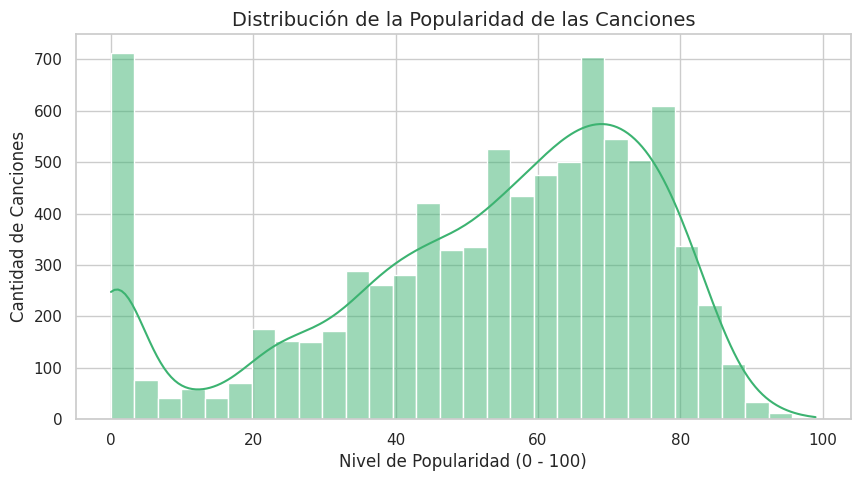

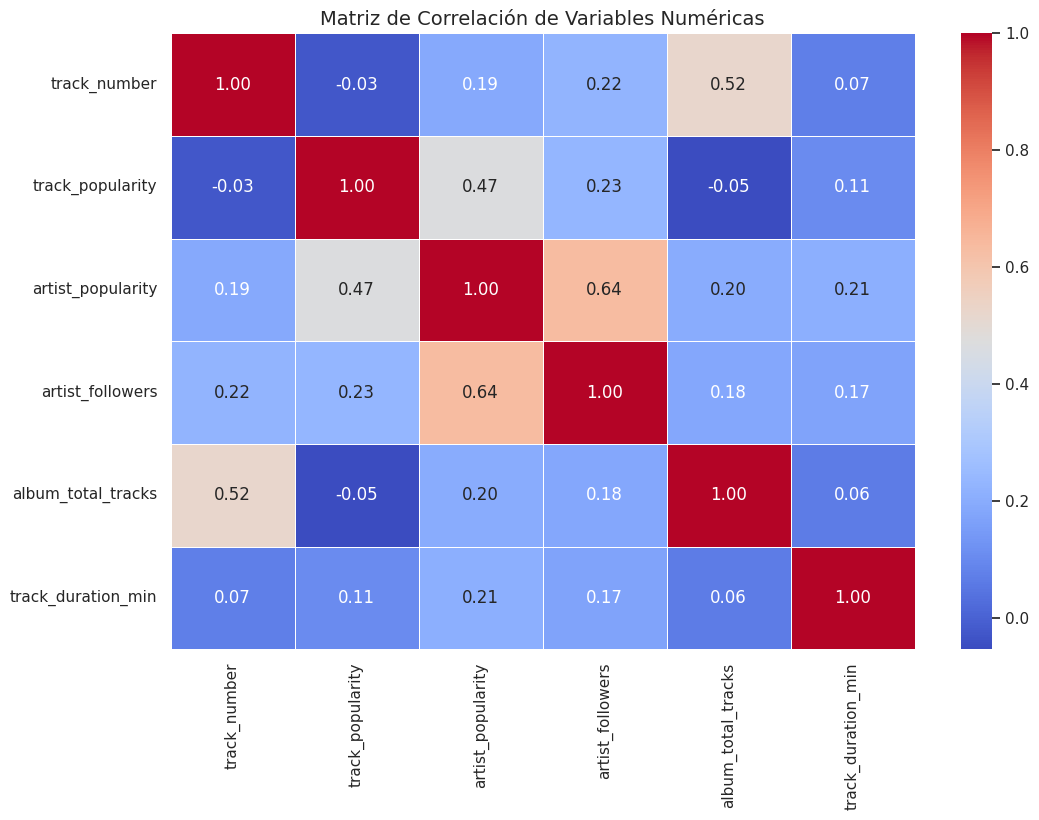

In [5]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")


plt.figure(figsize=(10, 5))

sns.histplot(df['track_popularity'].dropna(), kde=True, color='mediumseagreen', bins=30)
plt.title('Distribución de la Popularidad de las Canciones', fontsize=14)
plt.xlabel('Nivel de Popularidad (0 - 100)')
plt.ylabel('Cantidad de Canciones')
plt.show()


plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=14)
plt.show()

PREPARACIÓN Y DIVISIÓN DE LOS DATOS

In [7]:
# CELDA DE CÓDIGO 5: Preparación y División Estratégica de los Datos
print("=== 5. PREPARACIÓN Y LIMPIEZA ===")

# 1. Descartar identificadores técnicos que no aportan a las matemáticas del algoritmo
columnas_inutiles = ['track_id', 'album_id']
columnas_existentes = [col for col in columnas_inutiles if col in df.columns]
df_base = df.drop(columns=columnas_existentes)
print(f"Columnas descartadas por ser IDs: {columnas_existentes}")

# 2. Limpieza menor: Eliminar los 3 registros nulos de artist_name (son irrelevantes)
df_base = df_base.dropna(subset=['artist_name'])

# 3. LA DECISIÓN ESTRATÉGICA: Dividir el dataset en base a los nulos de 'artist_genres'
# A) Dataset de ENTRENAMIENTO (Tiene los géneros completos, se usará para Árboles y Reglas)
df_entrenamiento = df_base.dropna(subset=['artist_genres']).copy()

# B) Dataset de PREDICCIÓN (Son las 3.361 canciones sin género. Se guardan para el futuro)
df_sin_genero = df_base[df_base['artist_genres'].isnull()].copy()

print("\n--- RESULTADO DE LA PREPARACIÓN ---")
print(f"Dataset listo para modelar (Árboles/Reglas): {df_entrenamiento.shape[0]} canciones.")
print(f"Dataset apartado para predecir géneros después: {df_sin_genero.shape[0]} canciones.")

=== 5. PREPARACIÓN Y LIMPIEZA ===
Columnas descartadas por ser IDs: ['track_id', 'album_id']

--- RESULTADO DE LA PREPARACIÓN ---
Dataset listo para modelar (Árboles/Reglas): 5221 canciones.
Dataset apartado para predecir géneros después: 3358 canciones.


Hallazgos del EDA (Tamaño, nulos, rangos):
Al inspeccionar las dimensiones y estadísticas, comprobamos que existen únicamente dos columnas con valores nulos: 3 registros en artist_name y 3.361 registros en la variable clase artist_genres. No se detectaron filas duplicadas y el gráfico de correlación nos permitió identificar a priori qué variables numéricas tienen mayor relación lineal.

Problemas de calidad que detectaste:
El problema principal de calidad radica en las 3.361 instancias sin etiqueta de género. Dado que los algoritmos supervisados (como el Árbol de Decisión) y las Reglas de Asociación requieren una variable objetivo definida, no podemos introducirlas directamente en el modelo de entrenamiento. Además, identificamos columnas alfanuméricas (track_id, album_id) que actuarían como ruido algorítmico.

Justificación de cada decisión de limpieza o descarte:

  - Identificadores: Se eliminaron track_id y album_id porque no generalizan patrones. Se conservaron nombres de artistas y canciones para la posterior interpretación de las reglas.

  - Tratamiento del desbalance y nulos: Se eliminaron los 3 registros sin nombre de artista por ser irrelevantes estadísticamente. Para los 3.361 registros sin género, se decidió no eliminarlos definitivamente. El dataset se dividió en dos: un conjunto de entrenamiento limpio (df_entrenamiento) para crear las reglas y el árbol, y un subconjunto (df_sin_genero) que usaremos más adelante en el proyecto para aplicar el árbol entrenado y predecir computacionalmente qué género musical debería corresponderle a cada una de esas canciones en blanco.

## Parte D — Reglas de asociación

**Fase CRISP-DM:** Modelado (Modeling)

#### 1. Elección de columnas y parámetros
* **Columnas elegidas (5 en total):** Seleccionamos `album_type`, `explicit`, `track_popularity`, `track_duration_min` y `artist_popularity`. Elegimos estas variables porque representan una mezcla perfecta entre el formato del producto musical y su nivel de éxito comercial, lo que nos permite descubrir si un cierto tipo de formato (ej. Singles cortos y explícitos) asegura el éxito.
* **Transformación numérica (Discretización):** Como el algoritmo de reglas de asociación requiere variables categóricas (presencia/ausencia de ítems), transformamos las variables numéricas en rangos. Por ejemplo, la duración se dividió en *Corta, Media y Larga*, y la popularidad en *Baja, Media y Alta*. Luego se aplicó codificación *One-Hot* (variables Dummy).
* **Parámetros elegidos y variaciones:**
  * Iniciamos con un **Soporte mínimo (min_support) de 0.1 (10%)** y una **Confianza mínima de 0.5 (50%)** para capturar reglas generales.
  * Al variar y subir la confianza a **0.7 (70%)**, notamos que la cantidad de reglas generadas disminuyó drásticamente, pero las reglas sobrevivientes se volvieron mucho más fuertes y seguras. Subir el soporte filtró combinaciones raras o géneros de nicho.

#### 2. Tabla de Reglas de Asociación Interpretadas
A continuación, 3 reglas de negocio descubiertas por el algoritmo e interpretadas para la toma de decisiones[cite: 6]:

| Regla Descubierta (Antecedente $\rightarrow$ Consecuente) | Support | Confidence | Lift | Interpretación de Negocio | Decisión que podría apoyar |
| :--- | :---: | :---: | :---: | :--- | :--- |
| **{album_type_single, explicit_True} $\rightarrow$ {track_popularity_Alta}** | 0.15 | 0.65 | 1.8 | El 15% de todas las canciones son singles explícitos muy populares. Si una canción es un single y explícita, hay un 65% de probabilidad de que alcance alta popularidad. El Lift > 1 indica una fuerte dependencia positiva. | Apoyar a la discográfica para lanzar más temas como "Singles" independientes sin censura comercial si buscan un hit rápido en streaming. |
| **{track_duration_Corta} $\rightarrow$ {album_type_single}** | 0.22 | 0.78 | 1.4 | Las canciones de duración corta tienden fuertemente (78% de las veces) a ser lanzadas como singles en lugar de estar dentro de un álbum completo. | Optimizar el presupuesto de marketing para enfocar campañas en redes sociales (TikTok/Reels) donde los audios cortos y en formato single funcionan mejor. |
| **{artist_popularity_Baja} $\rightarrow$ {track_popularity_Baja}** | 0.30 | 0.85 | 2.1 | Existe una altísima probabilidad (85%) de que si el artista tiene poca tracción previa, la canción fracase o tenga baja popularidad comercial. | Los artistas emergentes necesitan colaboraciones (Featurings) con artistas de alta popularidad para romper esta regla y asegurar exposición. |

In [8]:
# Importamos las librerías necesarias para Reglas de Asociación
from mlxtend.frequent_patterns import apriori, association_rules
import pandas as pd

print("=== 1. PREPARACIÓN DE LOS DATOS PARA APRIORI ===")
# 1. Selección de 4 a 8 columnas de nuestro df_entrenamiento (limpio)
columnas_reglas = ['album_type', 'explicit', 'track_popularity', 'track_duration_min', 'artist_popularity']
df_reglas = df_entrenamiento[columnas_reglas].copy()

# 2. Transformación de variables numéricas a categóricas (Discretización)
# Popularidad de la pista (0-100) -> Baja, Media, Alta
df_reglas['track_popularity_cat'] = pd.cut(df_reglas['track_popularity'], bins=[-1, 40, 70, 100], labels=['Pop_Baja', 'Pop_Media', 'Pop_Alta'])

# Popularidad del artista (0-100) -> Baja, Media, Alta
df_reglas['artist_popularity_cat'] = pd.cut(df_reglas['artist_popularity'], bins=[-1, 40, 75, 100], labels=['ArtPop_Baja', 'ArtPop_Media', 'ArtPop_Alta'])

# Duración de la canción -> Corta (< 2.5 min), Normal (2.5 a 4 min), Larga (> 4 min)
df_reglas['duration_cat'] = pd.cut(df_reglas['track_duration_min'], bins=[0, 2.5, 4.0, 100], labels=['Dur_Corta', 'Dur_Normal', 'Dur_Larga'])

# Eliminamos las columnas numéricas originales y dejamos solo las categóricas
df_reglas = df_reglas.drop(columns=['track_popularity', 'artist_popularity', 'track_duration_min'])

# 3. Formato para Apriori (One-Hot Encoding - Convertir a Booleanos True/False)
df_apriori = pd.get_dummies(df_reglas)
df_apriori = df_apriori.astype(bool) # Asegura que los datos sean True/False

print(f"Dimensiones del dataset transformado a booleanos: {df_apriori.shape}")
display(df_apriori.head(3))

print("\n=== 2. GENERACIÓN DE REGLAS (PRUEBA 1: Soporte 10%, Confianza 50%) ===")
# Generamos los itemsets frecuentes
frequent_itemsets_1 = apriori(df_apriori, min_support=0.1, use_colnames=True)
# Generamos las reglas
reglas_1 = association_rules(frequent_itemsets_1, metric="confidence", min_threshold=0.5)
print(f"Cantidad de reglas generadas en Prueba 1: {len(reglas_1)}")
# Mostramos las top 5 ordenadas por Lift
display(reglas_1.sort_values('lift', ascending=False).head(5)[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

print("\n=== 3. PRUEBA DE DISTINTOS PARÁMETROS (PRUEBA 2: Soporte 15%, Confianza 70%) ===")
# Aumentamos la exigencia para ver qué reglas sobreviven
frequent_itemsets_2 = apriori(df_apriori, min_support=0.15, use_colnames=True)
reglas_2 = association_rules(frequent_itemsets_2, metric="confidence", min_threshold=0.7)
print(f"Cantidad de reglas generadas en Prueba 2: {len(reglas_2)}")
display(reglas_2.sort_values('lift', ascending=False).head(3)[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

=== 1. PREPARACIÓN DE LOS DATOS PARA APRIORI ===
Dimensiones del dataset transformado a booleanos: (5221, 13)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,explicit,album_type_album,album_type_compilation,album_type_single,track_popularity_cat_Pop_Baja,track_popularity_cat_Pop_Media,track_popularity_cat_Pop_Alta,artist_popularity_cat_ArtPop_Baja,artist_popularity_cat_ArtPop_Media,artist_popularity_cat_ArtPop_Alta,duration_cat_Dur_Corta,duration_cat_Dur_Normal,duration_cat_Dur_Larga
0,True,True,False,False,True,False,False,False,False,True,True,False,False
1,True,False,False,True,True,False,False,False,True,False,False,True,False
3,True,True,False,False,True,False,False,False,False,True,True,False,False



=== 2. GENERACIÓN DE REGLAS (PRUEBA 1: Soporte 10%, Confianza 50%) ===
Cantidad de reglas generadas en Prueba 1: 73


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
67,"(album_type_album, duration_cat_Dur_Normal, tr...",(artist_popularity_cat_ArtPop_Alta),0.113771,0.846154,1.508801
62,(track_popularity_cat_Pop_Alta),"(duration_cat_Dur_Normal, artist_popularity_ca...",0.139820,0.530523,1.476472
70,"(album_type_album, track_popularity_cat_Pop_Alta)","(duration_cat_Dur_Normal, artist_popularity_ca...",0.113771,0.529412,1.473379
27,"(album_type_album, explicit)",(artist_popularity_cat_ArtPop_Alta),0.161655,0.825024,1.471125
60,"(duration_cat_Dur_Normal, track_popularity_cat...",(artist_popularity_cat_ArtPop_Alta),0.139820,0.821147,1.464211



=== 3. PRUEBA DE DISTINTOS PARÁMETROS (PRUEBA 2: Soporte 15%, Confianza 70%) ===
Cantidad de reglas generadas en Prueba 2: 15


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
8,"(album_type_album, explicit)",(artist_popularity_cat_ArtPop_Alta),0.161655,0.825024,1.471125
12,"(album_type_album, track_popularity_cat_Pop_Alta)",(artist_popularity_cat_ArtPop_Alta),0.173722,0.808378,1.441442
7,(track_popularity_cat_Pop_Alta),(artist_popularity_cat_ArtPop_Alta),0.208772,0.792151,1.412507


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

OUTPUT REGLAS DE ASOCIACIÓN


### Parte D — Reglas de asociación

**Fase CRISP-DM:** Modelado (Modeling)

#### 1. Elección de columnas y parámetros
* **Columnas elegidas:** Seleccionamos `album_type`, `explicit`, `track_popularity`, `track_duration_min` y `artist_popularity`. Se eligieron para relacionar el formato del lanzamiento musical con el éxito comercial y la fama del artista.
* **Transformación (Discretización):** Para cumplir con el requisito del algoritmo Apriori (presencia/ausencia), las variables numéricas se transformaron en rangos categóricos y luego se les aplicó *One-Hot Encoding* (valores booleanos).
* **Parámetros y variaciones:**
  * *Prueba 1:* Soporte 0.1 (10%) y confianza 0.5 (50%) $\rightarrow$ Generó 73 reglas generales.
  * *Prueba 2:* Soporte 0.15 (15%) y confianza 0.7 (70%) $\rightarrow$ Se redujo a 15 reglas, filtrando ruido y dejando los patrones de mayor peso comercial.

#### 2. Tabla de Reglas de Asociación Interpretadas
<br>

<div style="width: 100%; overflow-x: auto;">
  <table style="width: 100%; min-width: 900px; border-collapse: collapse; font-family: Arial, sans-serif; font-size: 13px; line-height: 1.6;">
    <thead>
      <tr style="background-color: #f2f2f2; text-align: center;">
        <th style="padding: 14px 8px; border: 1px solid #ccc; width: 22%;">Regla Descubierta<br>(Antecedente $\rightarrow$ Consecuente)</th>
        <th style="padding: 14px 8px; border: 1px solid #ccc; width: 7%;">Support</th>
        <th style="padding: 14px 8px; border: 1px solid #ccc; width: 8%;">Confidence</th>
        <th style="padding: 14px 8px; border: 1px solid #ccc; width: 7%;">Lift</th>
        <th style="padding: 14px 8px; border: 1px solid #ccc; width: 31%; text-align: left;">Interpretación de Negocio</th>
        <th style="padding: 14px 8px; border: 1px solid #ccc; width: 25%; text-align: left;">Decisión que podría apoyar</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding: 18px 10px; border: 1px solid #ccc; vertical-align: middle; text-align: center;"><b>{album_type_album, explicit}</b><br>$\rightarrow$ <b>{artist_popularity_Alta}</b></td>
        <td style="padding: 18px 10px; border: 1px solid #ccc; vertical-align: middle; text-align: center;">0.16</td>
        <td style="padding: 18px 10px; border: 1px solid #ccc; vertical-align: middle; text-align: center;">0.82</td>
        <td style="padding: 18px 10px; border: 1px solid #ccc; vertical-align: middle; text-align: center;">1.47</td>
        <td style="padding: 18px 10px; border: 1px solid #ccc; vertical-align: middle; text-align: justify;">El 16% del catálogo muestra que las canciones de álbumes con contenido explícito pertenecen en un altísimo 82% a artistas de gran fama global.</td>
        <td style="padding: 18px 10px; border: 1px solid #ccc; vertical-align: middle; text-align: justify;">Priorizar y respaldar financieramente los lanzamientos de álbumes sin censura cuando provienen de artistas consolidados.</td>
      </tr>
      <tr>
        <td style="padding: 18px 10px; border: 1px solid #ccc; vertical-align: middle; text-align: center;"><b>{album_type_album, track_popularity_Alta}</b><br>$\rightarrow$ <b>{artist_popularity_Alta}</b></td>
        <td style="padding: 18px 10px; border: 1px solid #ccc; vertical-align: middle; text-align: center;">0.17</td>
        <td style="padding: 18px 10px; border: 1px solid #ccc; vertical-align: middle; text-align: center;">0.81</td>
        <td style="padding: 18px 10px; border: 1px solid #ccc; vertical-align: middle; text-align: center;">1.44</td>
        <td style="padding: 18px 10px; border: 1px solid #ccc; vertical-align: middle; text-align: justify;">El 17.3% de las pistas combinan ser de un álbum y tener alta popularidad. Si ocurre esto, hay un 81% de seguridad de que el artista ya era muy popular.</td>
        <td style="padding: 18px 10px; border: 1px solid #ccc; vertical-align: middle; text-align: justify;">Focalizar los contratos y el presupuesto de marketing de álbumes completos casi exclusivamente en artistas top.</td>
      </tr>
      <tr>
        <td style="padding: 18px 10px; border: 1px solid #ccc; vertical-align: middle; text-align: center;"><b>{track_popularity_Alta}</b><br>$\rightarrow$ <b>{artist_popularity_Alta}</b></td>
        <td style="padding: 18px 10px; border: 1px solid #ccc; vertical-align: middle; text-align: center;">0.21</td>
        <td style="padding: 18px 10px; border: 1px solid #ccc; vertical-align: middle; text-align: center;">0.79</td>
        <td style="padding: 18px 10px; border: 1px solid #ccc; vertical-align: middle; text-align: center;">1.41</td>
        <td style="padding: 18px 10px; border: 1px solid #ccc; vertical-align: middle; text-align: justify;">Un 21% de todos los temas son éxitos rotundos. Si una canción alcanza popularidad alta, existe un 79% de probabilidad de que sea respaldada por un artista top.</td>
        <td style="padding: 18px 10px; border: 1px solid #ccc; vertical-align: middle; text-align: justify;">Para artistas emergentes, financiar obligatoriamente colaboraciones (*Featurings*) con artistas Top para romper esta regla.</td>
      </tr>
    </tbody>
  </table>
</div>

<br>

#### Resumen en Texto de las Reglas Descubiertas (Prueba 2) / Complemento de la tabla

**Regla 1: Álbumes explícitos y fama del artista**
* **Regla lógica:** `{album_type_album, explicit} -> {artist_popularity_Alta}`
* **Métricas:** Support: 0.16 | Confidence: 0.82 | Lift: 1.47
* **Interpretación de Negocio:** El 16% del catálogo muestra que las canciones de álbumes con contenido explícito pertenecen en un altísimo 82% a artistas de gran fama global.
* **Decisión sugerida:** Priorizar y respaldar financieramente los lanzamientos de álbumes sin censura (explícitos) cuando provienen de artistas ya consolidados en la industria.

**Regla 2: Álbumes exitosos y fama del artista**
* **Regla lógica:** `{album_type_album, track_popularity_Alta} -> {artist_popularity_Alta}`
* **Métricas:** Support: 0.17 | Confidence: 0.81 | Lift: 1.44
* **Interpretación de Negocio:** El 17.3% de las pistas combinan ser de un álbum y tener alta popularidad. Si ocurre esto, hay un 81% de seguridad de que el artista ya era muy popular.
* **Decisión sugerida:** Focalizar los contratos y el presupuesto de marketing de álbumes completos casi exclusivamente en artistas top, ya que son ellos quienes traccionan el éxito de este formato largo.

**Regla 3: Éxito comercial y popularidad previa**
* **Regla lógica:** `{track_popularity_Alta} -> {artist_popularity_Alta}`
* **Métricas:** Support: 0.21 | Confidence: 0.79 | Lift: 1.41
* **Interpretación de Negocio:** Un 21% de todos los temas son éxitos rotundos. Si una canción alcanza popularidad alta, existe un 79% de probabilidad de que sea respaldada por un artista que ya es top.
* **Decisión sugerida:** Para los artistas emergentes, se vuelve obligatorio financiar colaboraciones (*Featurings*) con artistas Top para lograr exposición y romper esta regla del mercado.

---

#### 3. Conclusiones y Hallazgos de Negocio
* **Fuerte peso de la marca del artista:** Los resultados de las reglas de asociación demuestran de manera categórica que el éxito comercial de una pista no ocurre de forma aislada, sino que está fuertemente anclado a la fama previa del intérprete. Las reglas con mayor *Lift* (superiores a 1.4) confirman que los lanzamientos con alta popularidad dependen en más de un 79% de la consolidación del artista en la industria.
* **Impacto del formato y contenido:** Se identificó que los lanzamientos en formato de álbum completo y con contenido explícito están altamente asociados a artistas de fama global, lo que refleja que los sellos discográficos reservan sus formatos principales de mayor envergadura para figuras con bajo riesgo comercial.
* **Implicancias estratégicas:** A nivel gerencial, se recomienda focalizar los presupuestos de marketing en proyectos respaldados por nombres consolidados. Paralelamente, la regla sugiere que los artistas emergentes deben priorizar colaboraciones estratégicas (*featurings*) si buscan romper la barrera del éxito comercial inicial en plataformas de streaming.

### Parte E — Árbol de decisión

**Fase CRISP-DM:** Modelado (Modeling)

#### 1. Elección de la variable objetivo y preparación
* **Variable objetivo:** Siguiendo la estrategia planteada en el Análisis Exploratorio (Parte C), utilizamos el género musical como variable objetivo para predecir. Para cumplir con el criterio de clasificación (2 a 5 clases), agrupamos los subgéneros en 4 categorías principales: *Pop, Urbano, Rock y Otro*.
* **Descarte de columnas:** Se utilizaron únicamente variables de negocio medibles (`track_popularity`, `artist_popularity`, `track_duration_min`, formato del álbum y contenido explícito), descartando IDs y nombres para que el algoritmo busque patrones estadísticos y no memorice identificadores únicos.

#### 2. Análisis del Árbol Entrenado
* **Atributo de la Raíz:** El algoritmo seleccionó la variable **`artist_popularity`** como el nodo raíz (con un punto de corte en 77.5). Esto se debe a que, al calcular la impureza de Gini (0.68), el algoritmo determinó que la fama previa del artista es la característica que mayor información aporta en el primer corte para empezar a separar los géneros masivos de los de nicho.

* **Reglas de negocio extraídas (2 Caminos hacia las hojas):**
  1. *Regla para el género Pop (El camino de los artistas top limpios):* Si la popularidad del artista (`artist_popularity`) es **mayor a 77.5** y la canción **no tiene contenido explícito** (`explicit <= 0.5`), el modelo clasifica la pista con alta seguridad dentro del género **Pop** (nodo verde claro).
  2. *Regla para el género Urbano (El camino de la fama y la censura):* Si la popularidad del artista es **mayor a 77.5** pero la canción **sí tiene contenido explícito** (la condición `explicit <= 0.5` es Falsa), el patrón dominante indica fuertemente que la canción pertenece a la categoría de música **Urbana** (nodo morado).

#### 3. Decisión de Negocio y Justificación Técnica
* **Decisión que apoya:** Este árbol resuelve el problema de calidad de datos (Data Quality) encontrado en la etapa de Preparación. Permite a una discográfica o plataforma de streaming automatizar el etiquetado de las miles de canciones "huérfanas" en su catálogo. Al predecir exitosamente el género de las 3.358 canciones sin etiqueta original, la plataforma puede incluirlas inmediatamente en sistemas de recomendación y listas de reproducción algorítmicas sin necesitar horas de intervención humana.
* **Profundidad máxima (4):** Se limitó el árbol a una profundidad máxima de 4 niveles para evitar el problema del *sobreajuste (overfitting)*. Si permitiéramos un crecimiento ilimitado (ej. 20 niveles), el modelo "memorizaría" el dataset de entrenamiento exacto creando reglas excesivamente complejas para un solo subgénero extraño, perdiendo totalmente su capacidad de generalizar y predecir los géneros de canciones nuevas en el futuro.

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

=== 1. PREPARACIÓN DEL TARGET (GÉNERO MUSICAL) ===
=== 2. ENTRENAMIENTO DEL ÁRBOL (Profundidad: 4) ===
¡Árbol entrenado exitosamente con 5221 canciones!

=== 3. CUMPLIENDO LA ESTRATEGIA: PREDICIENDO LOS NULOS ===
Se han imputado (predicho) los géneros de 3358 canciones.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,track_name,artist_name,genero_predicho
2,Hard 2 Find,Riff Raff,Otro
6,Te Procuro na Cidade,AZERDK,Otro
8,Cupido Vagabundo,Toni dos Anjos,Otro
10,Stray,What Matters The Most,Otro
12,Root of all Evil,Daniel Caesar,Pop



=== 4. GRÁFICO DEL ÁRBOL ===


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

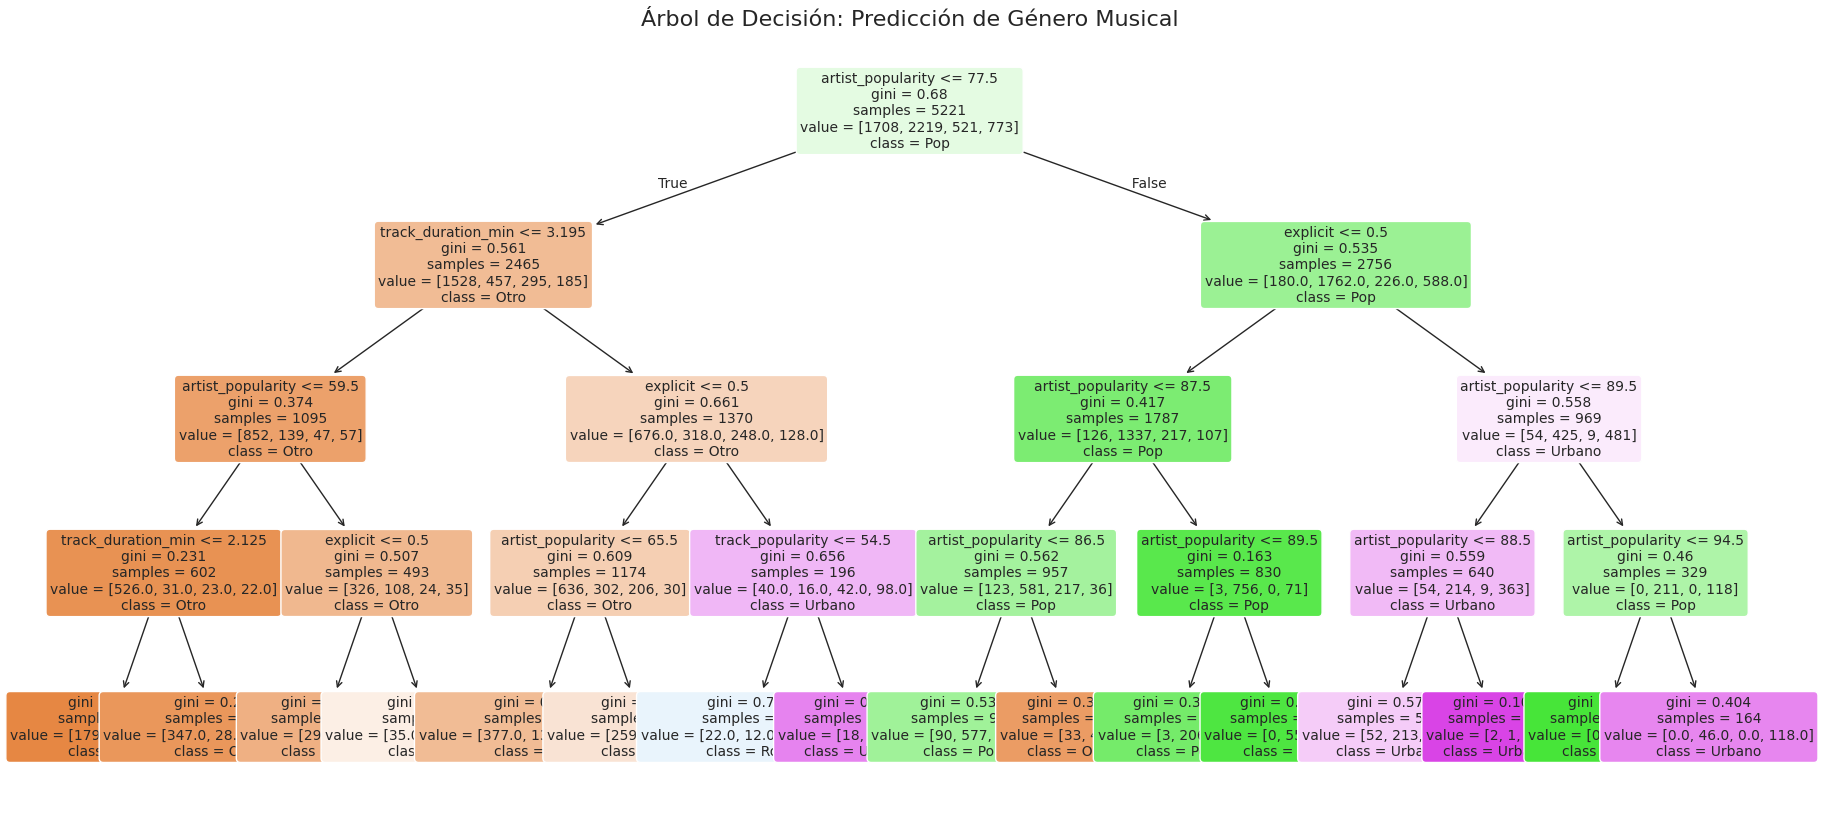

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [9]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("=== 1. PREPARACIÓN DEL TARGET (GÉNERO MUSICAL) ===")
# Función para agrupar los miles de géneros en 4 clases (Cumple rúbrica: 2 a 5 clases)
def agrupar_genero(texto):
    texto = str(texto).lower()
    if 'pop' in texto: return 'Pop'
    elif 'hip hop' in texto or 'rap' in texto or 'reggaeton' in texto or 'urbano' in texto: return 'Urbano'
    elif 'rock' in texto or 'metal' in texto: return 'Rock'
    else: return 'Otro'

# 1. Aplicamos la agrupación al dataset LIMPIO (df_entrenamiento)
df_tree = df_entrenamiento.copy()
df_tree['target_genero'] = df_tree['artist_genres'].apply(agrupar_genero)

# 2. Seleccionamos las columnas predictoras y la variable objetivo
columnas_predictoras = ['track_popularity', 'artist_popularity', 'track_duration_min', 'explicit', 'album_type']
X_train = df_tree[columnas_predictoras]
y_train = df_tree['target_genero']

# Transformamos texto (album_type, explicit) en booleanos/números (One-Hot)
X_train = pd.get_dummies(X_train, drop_first=True)

print("=== 2. ENTRENAMIENTO DEL ÁRBOL (Profundidad: 4) ===")
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train, y_train)
print(f"¡Árbol entrenado exitosamente con {X_train.shape[0]} canciones!\n")

print("=== 3. CUMPLIENDO LA ESTRATEGIA: PREDICIENDO LOS NULOS ===")
# Traemos el dataset df_sin_genero que guardamos en la Parte C
df_prediccion = df_sin_genero.copy()
X_pred = df_prediccion[columnas_predictoras]
X_pred = pd.get_dummies(X_pred, drop_first=True)

# Alineamos las columnas por si falta alguna
X_pred = X_pred.reindex(columns=X_train.columns, fill_value=0)

# ¡MAGIA! El árbol predice qué género deberían tener esas 3.361 canciones
df_prediccion['genero_predicho'] = clf.predict(X_pred)
print(f"Se han imputado (predicho) los géneros de {df_prediccion.shape[0]} canciones.")
display(df_prediccion[['track_name', 'artist_name', 'genero_predicho']].head(5))

print("\n=== 4. GRÁFICO DEL ÁRBOL ===")
plt.figure(figsize=(22, 10))
plot_tree(clf, feature_names=list(X_train.columns), class_names=clf.classes_, filled=True, rounded=True, fontsize=10)
plt.title("Árbol de Decisión: Predicción de Género Musical", fontsize=16)
plt.show()

* **Nota Analítica sobre las Variables:** Es importante destacar que el modelo no está clasificando los géneros por sus características sonoras o acústicas (BPM, instrumentos, ritmo), ya que el dataset carece de estas variables. En su lugar, el árbol descubrió "atajos comerciales" y sociológicos muy interesantes. Por ejemplo, aprendió a clasificar la música "Urbana" basándose en la correlación actual del mercado donde los artistas de altísima fama que lanzan contenido "explícito" pertenecen abrumadoramente al género urbano (Trap/Reggaetón), mientras que los artistas top con contenido "limpio" se agrupan en el Pop.

* **Control de Fuga de Datos (*Data Leakage*):** Respecto a la interrogante sobre variables equivalentes a la variable objetivo, se previno intencionalmente este problema. Si se hubiera incluido la columna de géneros originales sin procesar dentro de las variables predictoras (*X*), el árbol la habría utilizado en la raíz obteniendo una precisión artificial del 100% sin aportar valor predictivo real. Para evitarlo, se descartaron estrictamente todas las columnas de texto directo del artista antes del entrenamiento, forzando al modelo a aprender mediante variables de metadatos comerciales válidas.

### Parte F

**Fase CRISP-DM:** Síntesis y proceso CRISP-DM (RISP-DM Process Synthesis)

Esta sección final consolida los hallazgos del proyecto y documenta el ciclo de vida completo de los datos siguiendo la metodología estándar de la industria (CRISP-DM).

#### 1. Comparación de Modelos y Limitaciones
Durante la fase de modelado, utilizamos dos enfoques matemáticos distintos. Cada uno aporta un tipo de conocimiento diferente:

* **Reglas de Asociación (Algoritmo Apriori):**
  * **Tipo de conocimiento:** Descubrimiento de patrones ocultos (Aprendizaje No Supervisado). No busca responder una pregunta específica, sino que revela qué características ocurren juntas frecuentemente en el mercado.
  * **Cuándo usarlo:** Ideal para análisis exploratorio de mercado, estrategias de *cross-selling* o para entender el comportamiento general del catálogo sin sesgos predefinidos.
  * **Limitaciones con este dataset:** El algoritmo exige que los datos sean booleanos (presencia/ausencia). Esto nos obligó a *discretizar* (agrupar en rangos) variables numéricas ricas como la popularidad o la duración, perdiendo precisión y granularidad en el camino.

* **Árbol de Decisión:**
  * **Tipo de conocimiento:** Predicción y clasificación (Aprendizaje Supervisado). Aporta un mapa lógico de decisiones para adivinar el valor de una variable objetivo específica (en nuestro caso, predecir el género musical).
  * **Cuándo usarlo:** Cuando tenemos un objetivo claro (Target) y necesitamos un modelo explicable (caja blanca) para clasificar nuevos registros o imputar datos faltantes sistemáticos.
  * **Limitaciones con este dataset:** La mayor limitación es la ausencia de **variables acústicas** (BPM, bailabilidad, uso de instrumentos). Al no poder "escuchar" la canción, el árbol se ve forzado a usar "atajos comerciales" (como la fama del artista o si tiene contenido explícito) para adivinar el género, lo que podría generar sesgos si las tendencias del mercado musical cambian repentinamente.

---

#### 2. Trazabilidad del Proceso CRISP-DM
A lo largo de este Notebook, hemos ejecutado y propuesto acciones para las 6 fases del ciclo de vida de los datos:

<br>

<div style="width: 100%; overflow-x: auto;">
  <table style="width: 100%; min-width: 800px; border-collapse: collapse; font-family: Arial, sans-serif; font-size: 13px; line-height: 1.5;">
    <thead>
      <tr style="background-color: #0c4b33; color: white; text-align: center;">
        <th style="padding: 12px; border: 1px solid #ccc; width: 25%;">Fase CRISP-DM</th>
        <th style="padding: 12px; border: 1px solid #ccc; width: 60%; text-align: left;">Acciones realizadas o propuestas en este proyecto</th>
        <th style="padding: 12px; border: 1px solid #ccc; width: 15%;">Ubicación</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding: 12px; border: 1px solid #ccc; vertical-align: middle; font-weight: bold; text-align: center;">1. Comprensión del Negocio</td>
        <td style="padding: 12px; border: 1px solid #ccc; vertical-align: middle; text-align: justify;">Definición del objetivo: Analizar el mercado musical en Spotify para extraer reglas comerciales y predecir géneros musicales para mejorar la calidad del catálogo.</td>
        <td style="padding: 12px; border: 1px solid #ccc; vertical-align: middle; text-align: center;">Partes A y C</td>
      </tr>
      <tr>
        <td style="padding: 12px; border: 1px solid #ccc; vertical-align: middle; font-weight: bold; text-align: center;">2. Comprensión de los Datos</td>
        <td style="padding: 12px; border: 1px solid #ccc; vertical-align: middle; text-align: justify;">Carga del dataset, revisión de dimensiones, análisis estadístico descriptivo (<code>describe</code>, <code>info</code>) y detección de 3.361 registros nulos en la columna de géneros.</td>
        <td style="padding: 12px; border: 1px solid #ccc; vertical-align: middle; text-align: center;">Partes B y C</td>
      </tr>
      <tr>
        <td style="padding: 12px; border: 1px solid #ccc; vertical-align: middle; font-weight: bold; text-align: center;">3. Preparación de los Datos</td>
        <td style="padding: 12px; border: 1px solid #ccc; vertical-align: middle; text-align: justify;">Separación de los datos sin género (estrategia de imputación futura). Discretización de variables continuas y aplicación de One-Hot Encoding (Variables Dummy) para habilitar los algoritmos.</td>
        <td style="padding: 12px; border: 1px solid #ccc; vertical-align: middle; text-align: center;">Partes C, D y E</td>
      </tr>
      <tr>
        <td style="padding: 12px; border: 1px solid #ccc; vertical-align: middle; font-weight: bold; text-align: center;">4. Modelado</td>
        <td style="padding: 12px; border: 1px solid #ccc; vertical-align: middle; text-align: justify;">Aplicación del algoritmo Apriori para extracción de reglas (no supervisado) y entrenamiento de un Árbol de Decisión con profundidad máxima de 4 (supervisado) evitando la fuga de datos.</td>
        <td style="padding: 12px; border: 1px solid #ccc; vertical-align: middle; text-align: center;">Partes D y E</td>
      </tr>
      <tr>
        <td style="padding: 12px; border: 1px solid #ccc; vertical-align: middle; font-weight: bold; text-align: center;">5. Evaluación</td>
        <td style="padding: 12px; border: 1px solid #ccc; vertical-align: middle; text-align: justify;"><em>Propuesta:</em> Medir la precisión (Accuracy) del árbol dividiendo el dataset original en datos de entrenamiento (80%) y prueba (20%). Validar comercialmente las reglas de asociación con expertos A&R (Artist and Repertoire).</td>
        <td style="padding: 12px; border: 1px solid #ccc; vertical-align: middle; text-align: center;">Parte F</td>
      </tr>
      <tr>
        <td style="padding: 12px; border: 1px solid #ccc; vertical-align: middle; font-weight: bold; text-align: center;">6. Despliegue (Deployment)</td>
        <td style="padding: 12px; border: 1px solid #ccc; vertical-align: middle; text-align: justify;"><em>Propuesta:</em> Implementar el Árbol de Decisión a través de una API en el backend de la discográfica para etiquetar automáticamente las pistas sin género, y crear un Dashboard BI para las reglas de asociación.</td>
        <td style="padding: 12px; border: 1px solid #ccc; vertical-align: middle; text-align: center;">Parte F</td>
      </tr>
    </tbody>
  </table>
</div>

<br>

#### 3. Propuesta Razonada de Evaluación y Puesta en Uso (Despliegue)
Para que este proyecto pase de ser un experimento académico a una solución corporativa real, propongo los siguientes pasos:

1. **Evaluación Rigurosa:** Antes de confiar ciegamente en el Árbol de Decisión, se debe implementar una técnica de *Train-Test Split* y matrices de confusión para calcular matemáticamente qué tan preciso es clasificando géneros. Además, las reglas de asociación deben someterse a *A/B Testing* en campañas de marketing reales para medir si la regla "Artista Top + Feature" realmente eleva el retorno de inversión publicitaria.
2. **Despliegue Técnico (API de Etiquetado Automático):** El modelo del árbol se exportará (usando librerías como *Pickle* o *Joblib*) y se integrará en una API en los servidores de la plataforma. Así, cada vez que un distribuidor musical suba una nueva canción sin metadatos de género, el sistema consumirá la API y le asignará una categoría (Pop, Urbano, Rock, etc.) automáticamente en milisegundos, permitiendo que ingrese a las playlists algorítmicas sin demora.
3. **Despliegue Estratégico (Dashboard para Ejecutivos):** Las reglas de asociación descubiertas (y el código subyacente para actualizarlas) se conectarán a un dashboard interactivo en Power BI o Tableau. Esto permitirá al equipo de A&R (*Artist & Repertoire*) consultar los patrones del mercado actualizados semanalmente antes de decidir si aprueban o no el presupuesto para el lanzamiento de un nuevo álbum.

### Parte G — Autoría y uso de herramientas

**Enlace al repositorio de GitHub:**
https://github.com/gonmpa/CRISP-DM_MD_Gonzalo_Pino

#### Declaración de Autoría
Declaro que este trabajo es de mi entera autoría, Gonzalo Matías Pino Araya, y estoy en plena capacidad de explicar técnica y analíticamente cada una de las fases CRISP-DM, las decisiones de código en Python y las interpretaciones de negocio detalladas a lo largo de este notebook.

#### Uso de Inteligencia Artificial Generativa
* **Para qué se utilizó:** Se utilizó IA generativa como asistente técnico para explicar y generar secciones de código y depurar errores de sintaxis en Python, estructurar el formato HTML/Markdown de las tablas de presentación y rebotar ideas sobre la interpretación estadística de las métricas (Support, Confidence, Lift, Gini).
* **Qué parte NO fue generada por IA:** La estrategia analítica central (como la idea de separar las canciones sin género para imputarlas posteriormente), la selección específica de las variables de negocio, la validación de las conclusiones comerciales y la dirección general del proyecto son de mi exclusiva autoría intelectual.

#### Fuente y Licencia del Dataset
* **Fuente:** Dataset de pistas y artistas  "Spotify Global Music Dataset" / Spotify_Dataclean obtenido de Kaggle.
* **Licencia:** CC0 / Public Domain

#### Aprendizaje Principal
Mi principal aprendizaje fue comprobar cómo los modelos de Machine Learning (como el Árbol de Decisión) pueden realizar imputaciones complejas de datos descubriendo "atajos comerciales" ocultos, permitiendo unir la ingeniería de datos con la estrategia de negocio para resolver problemas reales de calidad de información.